In [29]:
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

load_dotenv()

True

In [2]:
geography_path = os.path.join(os.getenv('DATA_DIR'), 'geography_rank.csv')
df = pd.read_csv(geography_path)

In [3]:
df.head()

,avg_time,avg_views,bounce_rate,conversion_rate,sub_continent,view_rank,time_rank,bounce_rank,conversion_rank
0,46.445705,1.887536,0.650988,0.000314,Western Asia,17,17,16,12
1,198.665571,6.165447,0.323295,0.029565,Northern America,1,1,1,1
2,49.734470,1.839114,0.696845,0.000000,Northern Africa,18,16,18,17
3,138.491575,3.736264,0.513553,0.006593,Caribbean,2,2,2,2
4,90.637240,2.344955,0.614985,0.000000,Western Africa,13,8,14,17


<Axes: ylabel='sub_continent'>

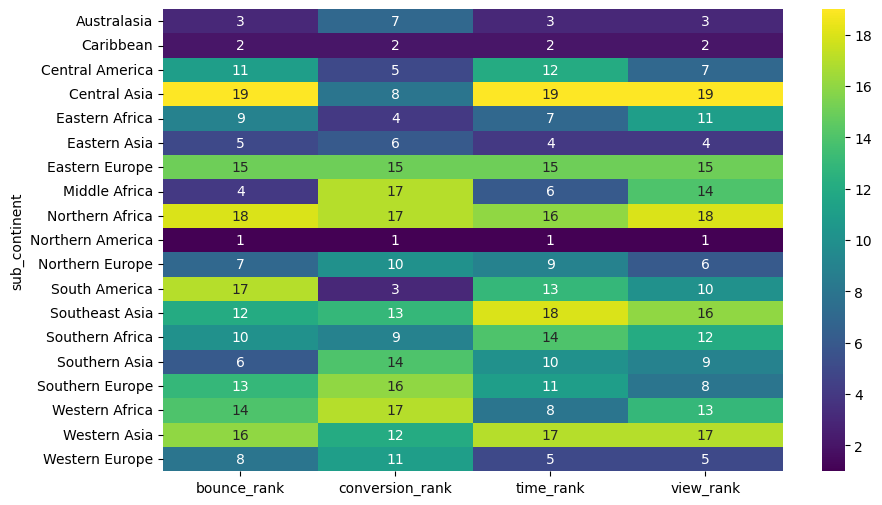

In [4]:
plt.figure(figsize=(10,6))
metrics = ['view_rank','time_rank','conversion_rank','bounce_rank']
sns.heatmap(df.pivot_table(values=metrics,index='sub_continent'),annot=True,cmap='viridis')

In [8]:
Volume_v_path = os.path.join(os.getenv('DATA_DIR'), 'Volume_value.csv')
vf = pd.read_csv(Volume_v_path)
vf.head()

,total_revenue,total_visits,revenue_per_visit,traffic_medium,value_rank,volume_rank
0,73414.36,63678,1.152900,organic,3,2
1,79.71,7885,0.010109,affiliate,5,3
2,11701.49,3618,3.234243,cpm,1,5
3,25508.58,192973,0.132187,referral,4,1
4,7153.67,4105,1.742672,cpc,2,4


In [11]:
cf = vf.melt(id_vars=['traffic_medium'],value_vars=['value_rank','volume_rank'],value_name='Rank',var_name='Metric')

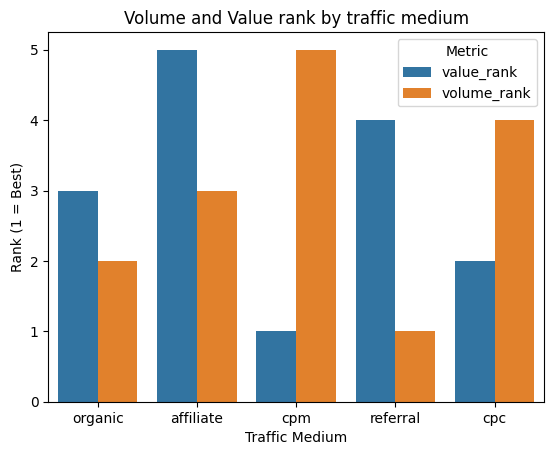

In [15]:
sns.barplot(cf,x='traffic_medium',y = 'Rank',hue='Metric')
plt.title("Volume and Value rank by traffic medium")
plt.xlabel("Traffic Medium")
plt.ylabel("Rank (1 = Best)")
plt.show()

In [37]:
cs_path = os.path.join(os.getenv('DATA_DIR'), 'customer_segment.csv')
cs = pd.read_csv(cs_path)
cs.head()

,visits,bounces,timeOnSite,pageviews,transactionRevenue,medium,subContinent
0,1,1.0,NaN,1.0,0.0,referral,Southern Europe
1,1,1.0,NaN,1.0,0.0,referral,Eastern Europe
2,1,1.0,NaN,1.0,0.0,(none),Southern Asia
3,1,1.0,NaN,1.0,0.0,(none),Eastern Asia
4,1,1.0,NaN,1.0,0.0,(none),Eastern Europe


In [40]:
cs['pageviews'] = cs['pageviews'].fillna(0)
cs['bounces'] =cs['bounces'].fillna(0)
cs['transactionRevenue'] = cs['transactionRevenue'].fillna(0)
cs['timeOnSite'] = cs['timeOnSite'].fillna(0)

In [41]:

cs_cluster = cs[cs['bounces'] == 0].copy()

cap = cs_cluster['pageviews'].quantile(0.99)

cs_cluster['pageviews_clipped'] = cs_cluster['pageviews'].clip(upper=cap)
cs_cluster['pageviews_log'] = np.log1p(cs_cluster['pageviews_clipped'])

cap = cs_cluster['transactionRevenue'].quantile(0.99)
cs_cluster['transactionRevenue_clipped'] = cs_cluster['transactionRevenue'].clip(upper=cap)
cs_cluster['transactionRevenue_log'] = np.log1p(cs_cluster['transactionRevenue_clipped'])

cap = cs_cluster['timeOnSite'].quantile(0.99)
cs_cluster['timeOnSite_clipped'] = cs_cluster['timeOnSite'].clip(upper=cap)
cs_cluster['timeOnSite_log'] = np.log1p(cs_cluster['timeOnSite_clipped'])

In [45]:
cs_cluster.describe()

,visits,bounces,timeOnSite,pageviews,transactionRevenue,pageviews_clipped,pageviews_log,transactionRevenue_clipped,transactionRevenue_log,timeOnSite_clipped,timeOnSite_log
count,85462.0,85462.0,85462.000000,85462.000000,85462.000000,85462.000000,85462.000000,85462.000000,85462.000000,85462.000000,85462.000000
mean,1.0,0.0,243.659088,6.725106,2.735858,6.508869,1.720028,0.851273,0.075514,234.179811,4.429524
std,0.0,0.0,468.134202,9.342638,66.474346,7.627640,0.689959,6.317846,0.522213,399.004658,1.479582
min,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.0,0.0,32.000000,2.000000,0.000000,2.000000,1.098612,0.000000,0.000000,32.000000,3.496508
50%,1.0,0.0,73.000000,3.000000,0.000000,3.000000,1.386294,0.000000,0.000000,73.000000,4.304065
75%,1.0,0.0,229.000000,7.000000,0.000000,7.000000,2.079442,0.000000,0.000000,229.000000,5.438079
max,1.0,0.0,11252.000000,327.000000,16023.750000,45.000000,3.828641,55.191700,4.028769,2204.000000,7.698483


In [46]:

features = ['pageviews_log', 'timeOnSite_log', 'transactionRevenue_log']
scaler = StandardScaler()
scaler.set_output(transform='pandas')
cs_scaled = scaler.fit_transform(cs_cluster[features])

In [50]:
from sklearn.metrics import silhouette_score

X = cs_scaled.sample(n=10000,random_state=42)
silhouette_scores = {}

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    silhouette_scores[k] = silhouette_score(X, labels)

print(silhouette_scores)

{2: 0.4945614021214249, 3: 0.5138679030310721, 4: 0.41906245221381816, 5: 0.41512126118538833, 6: 0.4395503523210709, 7: 0.3957170349403985, 8: 0.40872105012664944, 9: 0.39914525642891713}


In [48]:
kmean = KMeans(n_clusters=3,random_state=42)
cs_cluster['label'] = kmean.fit_predict(cs_cluster[features])

In [52]:


# Re-profile
cs_cluster.groupby('label')[['pageviews_log', 'timeOnSite_log', 'transactionRevenue_log']].mean()

,pageviews_log,timeOnSite_log,transactionRevenue_log
label,,,
0,1.535028,4.335885,0.000200
1,1.187281,2.505102,0.000000
2,2.517227,6.277635,0.276641


In [54]:
cs_cluster['label'] = cs_cluster['label'].replace({0: 'Engaged Browsers', 1: 'Minimal Engagers', 2: 'Buyers'})

In [55]:
geo_table = cs_cluster.groupby(['subContinent', 'label']).size().unstack(fill_value=0)
geo_pct = geo_table.div(geo_table.sum(axis=0), axis=1) * 100
geo_pct = geo_pct.sort_values('Buyers', ascending=False).head(5).round(2)
print(geo_pct)

label             Buyers  Engaged Browsers  Minimal Engagers
subContinent                                                
Northern America   65.92             45.75             49.35
Western Europe      5.45              4.68              5.07
Southern Asia       4.31              5.36              6.09
Northern Europe     4.12              4.53              5.30
Eastern Asia        4.00              4.00              4.62


In [61]:
med_table = cs_cluster.groupby(['medium', 'label']).size().unstack(fill_value=0)
med_pct = med_table.div(med_table.sum(axis=0), axis=1) * 100
med_pct = med_pct.sort_values('Buyers', ascending=False).round(2)
print(med_pct)

label      Buyers  Engaged Browsers  Minimal Engagers
medium                                               
(none)      68.16             48.52             51.14
organic     16.46             11.56             11.14
referral    10.68             36.63             34.66
affiliate    2.16              1.76              1.37
cpc          1.36              0.80              0.81
cpm          1.17              0.72              0.88


In [62]:
med_table

label,Buyers,Engaged Browsers,Minimal Engagers
medium,,,
(none),15881,20295,10401
affiliate,503,737,278
cpc,318,335,165
cpm,273,300,179
organic,3835,4837,2266
referral,2488,15321,7050
